## SPH6004 Individual Assignment

##### Student Name: Jing Ruowen		


### 1. Environment configuration and data import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,confusion_matrix, roc_curve)
from sklearn.model_selection import train_test_split, cross_val_score
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
np.random.seed(42)

In [13]:
# Import the dataset
data = pd.read_csv("Assignment1_mimic dataset.csv")
print("Shape of the dataset:", data.shape)
print("The distribution of the target variable (icu_death_flag):")
print(data["icu_death_flag"].value_counts(normalize=True).round(3))
#data.head()

Shape of the dataset: (65366, 140)
The distribution of the target variable (icu_death_flag):
icu_death_flag
0    0.913
1    0.087
Name: proportion, dtype: float64


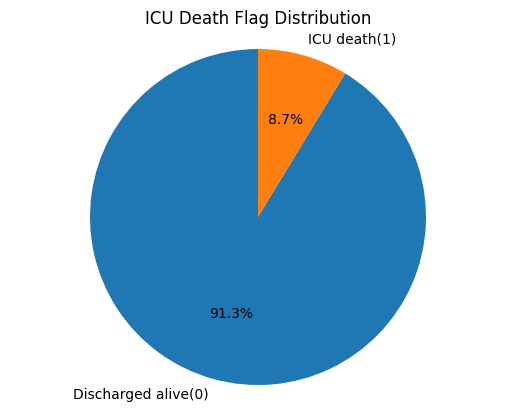

In [24]:
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  
plt.rcParams['axes.unicode_minus'] = False        
plt.rcParams['font.family'] = 'sans-serif'       

death_counts = data["icu_death_flag"].value_counts()

plt.pie(
    death_counts,
    labels=['Discharged alive(0)', 'ICU death(1)'],
    autopct='%1.1f%%',
    startangle=90  
)
plt.axis('equal') 
plt.title('ICU Death Flag Distribution')  
plt.show() 

### 2. Data Preprocessing

In [3]:
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

#### 2.1 Initial Data Inspection

##### The dataset used in this assignment includes 65366 samples and 140 features. First, the redundant time-related variables and non-predictive identifiers were removed, and ultimately 132 features were retained.

In [4]:
# Separate the feature X and the target variable y
exclude_cols = ["subject_id", "hadm_id", "stay_id", "intime", "outtime", 
               "deathtime", "hospital_expire_flag", "icu_death_flag"]
X = data.drop(exclude_cols, axis=1, errors="ignore")
y = data["icu_death_flag"].values  # 0= out of hospital, 1=ICU death
print(f"The number of original features after separation：{X.shape[1]} | sample size：{X.shape[0]}")

The number of original features after separation：132 | sample size：65366


#### 2.2 Handling Missing Values

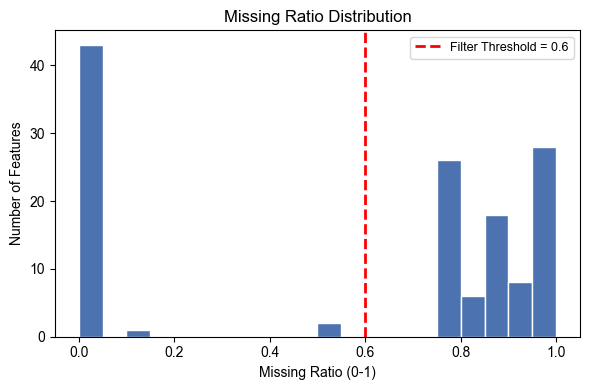

In [5]:
# Handling of high-frequency feature missing
missing_threshold = 0.6  
missing_ratio = X.isna().mean()

# Missing Ratio Distribution
plt.figure(figsize=(6, 4), dpi=100)
plt.hist(missing_ratio, bins=20, color="#4C72B0", edgecolor="white")
plt.axvline(missing_threshold, color="red", linestyle="--", linewidth=2,label=f"Filter Threshold = {missing_threshold}")
plt.title("Missing Ratio Distribution", fontsize=12)
plt.xlabel("Missing Ratio (0-1)", fontsize=10)
plt.ylabel("Number of Features", fontsize=10)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("missing_ratio_distribution.png", bbox_inches="tight")
plt.show()
plt.close()

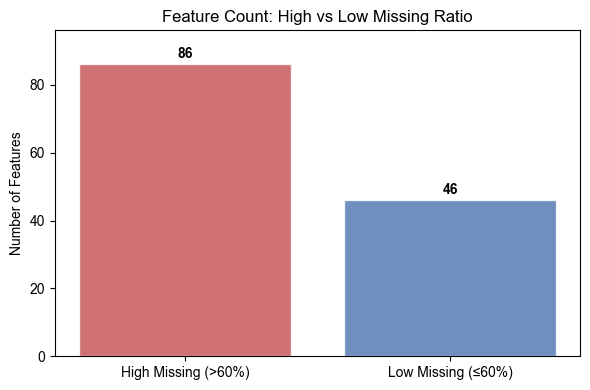

In [7]:
plt.figure(figsize=(6, 4), dpi=100)
categories = ["High Missing (>60%)", "Low Missing (≤60%)"]
counts = [len(high_missing_cols), len(low_missing_cols)]
colors = ["#C44E52", "#4C72B0"]
plt.bar(categories, counts, color=colors, alpha=0.8, edgecolor="white")

for i, count in enumerate(counts):
    plt.text(i, count+1, str(count), ha="center", va="bottom", fontweight="bold")
plt.title("Feature Count: High vs Low Missing Ratio", fontsize=12)
plt.ylabel("Number of Features", fontsize=10)
plt.ylim(0, max(counts) + 10)
plt.tight_layout()
plt.savefig("high_vs_low_missing_features.png", bbox_inches="tight")
plt.show()
plt.close()

##### To avoid the influence of high missing rate features on subsequent operations, they were eliminated

In [6]:
high_missing_cols = missing_ratio[missing_ratio > missing_threshold].index.tolist()
low_missing_cols = missing_ratio[missing_ratio <= missing_threshold].index.tolist()

# Remove features with high missing values
if high_missing_cols:
    X = X.drop(columns=high_missing_cols)

print(f"\nHigh Missing Feature Filter: Removed {len(high_missing_cols)} features with missing rate > {missing_threshold}")
print(f"Examples of high missing features: {high_missing_cols[:5] if high_missing_cols else 'None'}")
print(f"The number of remaining features after high missing filtering: {X.shape[1]}")


High Missing Feature Filter: Removed 86 features with missing rate > 0.6
Examples of high missing features: ['hematocrit_min', 'hematocrit_max', 'hemoglobin_min', 'hemoglobin_max', 'platelets_min']
The number of remaining features after high missing filtering: 46


#### 2.3 Feature Type Identification


Numeric Feature Number: 39, Categorical Feature Number: 7


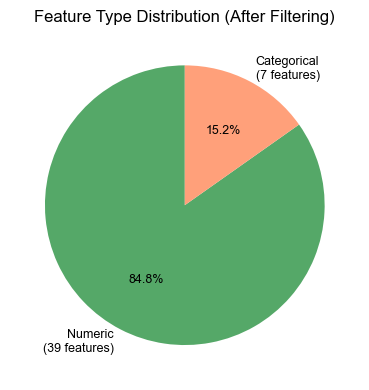

In [8]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nNumeric Feature Number: {len(numeric_cols)}, Categorical Feature Number: {len(cat_cols)}")

plt.figure(figsize=(6, 4), dpi=100)
sizes = [len(numeric_cols), len(cat_cols)]
labels = [f"Numeric\n({len(numeric_cols)} features)", f"Categorical\n({len(cat_cols)} features)"]
colors = ["#55A868", "#FFA07A"]
plt.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 9})
plt.title("Feature Type Distribution (After Filtering)", fontsize=12)
plt.tight_layout()
plt.savefig("feature_type_distribution.png", bbox_inches="tight")
plt.show()
plt.close()

#### 2.4 Missing Value Imputation
##### To handle the missing values, the filling is carried out separately based on the type of the features.For numerical features, the median is used for filling. For categorical features, the mode is used for filling.


Missing Value Imputation: 93244 → 0 (total missing values)


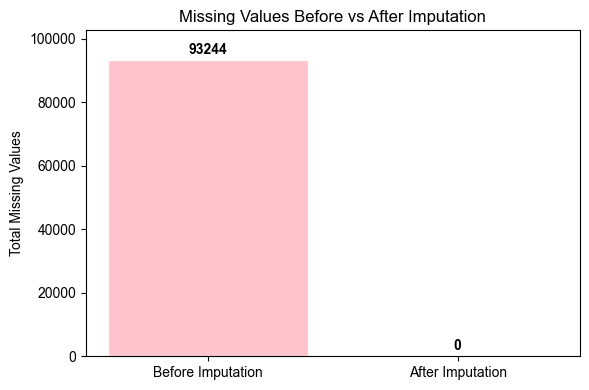

In [9]:
missing_before = X.isna().sum().sum()

# For numerical features, the median is used for filling
imputer_num = SimpleImputer(strategy="median")
X[numeric_cols] = imputer_num.fit_transform(X[numeric_cols])

# For categorical features, the mode is used for filling
imputer_cat = SimpleImputer(strategy="most_frequent")
X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])
missing_after = X.isna().sum().sum()

print(f"\nMissing Value Imputation: {missing_before} → {missing_after} (total missing values)")

plt.figure(figsize=(6, 4), dpi=100)
stages = ["Before Imputation", "After Imputation"]
missing_counts = [missing_before, missing_after]
plt.bar(stages, missing_counts, color=["#FFB6C1", "#90EE90"], alpha=0.8, edgecolor="white")

for i, count in enumerate(missing_counts):
    plt.text(i, count + max(missing_counts)*0.01, str(count), ha="center", va="bottom", fontweight="bold")
plt.title("Missing Values Before vs After Imputation", fontsize=12)
plt.ylabel("Total Missing Values", fontsize=10)
plt.ylim(0, max(missing_counts) * 1.1)
plt.tight_layout()
plt.savefig("missing_values_imputation_effect.png", bbox_inches="tight")
plt.show()
plt.close()

#### 2.5 Encoding and Standardization

In [10]:
# For the 7 categorical features, label encoding is adopted
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
print(f"\nCategorical Feature Encoding: Completed for {len(cat_cols)} features")

# For the 39 numerical features, StandardScaler is used for scaling
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
print(f"Numeric Feature Standardization: Completed for {len(numeric_cols)} features")

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

X_processed = X


Categorical Feature Encoding: Completed for 7 features
Numeric Feature Standardization: Completed for 39 features

Final feature matrix shape: (65366, 46)
Target variable shape: (65366,)


### 3. Feature Selection

In [26]:
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

feat_stage = {'Initial feature': X_processed.shape[1]}
original_features = X_processed.columns.tolist()
print(f"Feature selection begins: Initial number of features = {X_processed.shape[1]}, Sample Size = {X_processed.shape[0]}")

Feature selection begins: Initial number of features = 46, Sample Size = 65366


#### Phase 1: Initial Screening with Filter Method

In [28]:
# Variance Thresholding
vt = VarianceThreshold(threshold=0.01)  
X_var = vt.fit_transform(X_processed)  
var_support = vt.get_support()  

X_var = pd.DataFrame(X_var, columns=[original_features[i] for i, val in enumerate(var_support) if val])
feat_stage['After variance filtering'] = X_var.shape[1]
print(f"The number of features after variance filtering: {X_var.shape[1]}")

The number of features after variance filtering: 46


In [29]:
# Correlation Screening (for numeric features)
numeric_cols_var = X_var.select_dtypes(include=[np.number]).columns.tolist()

# Calculate Pearson correlation between each numeric feature and target
corr_scores = X_var[numeric_cols_var].corrwith(pd.Series(y))

# keep the features whose absolute value of the correlation coefficient is greater than 0.1
corr_support = abs(corr_scores) > 0.1
corr_features = corr_support[corr_support].index.tolist()
feat_stage['After correlation screening'] = len(corr_features)
print(f"The number of numerical features after correlation screening: {len(corr_features)}")

The number of numerical features after correlation screening: 26


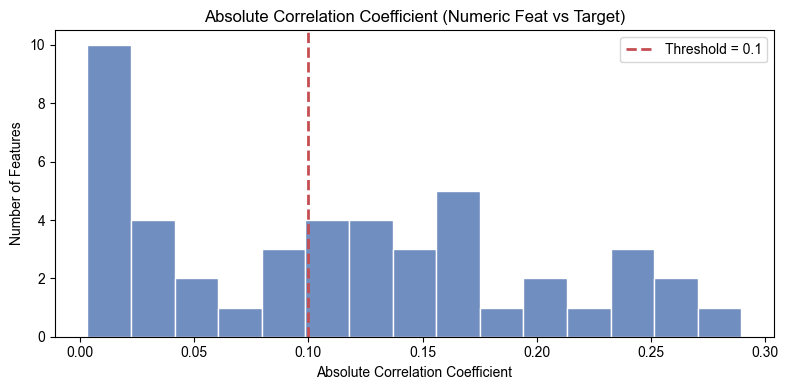

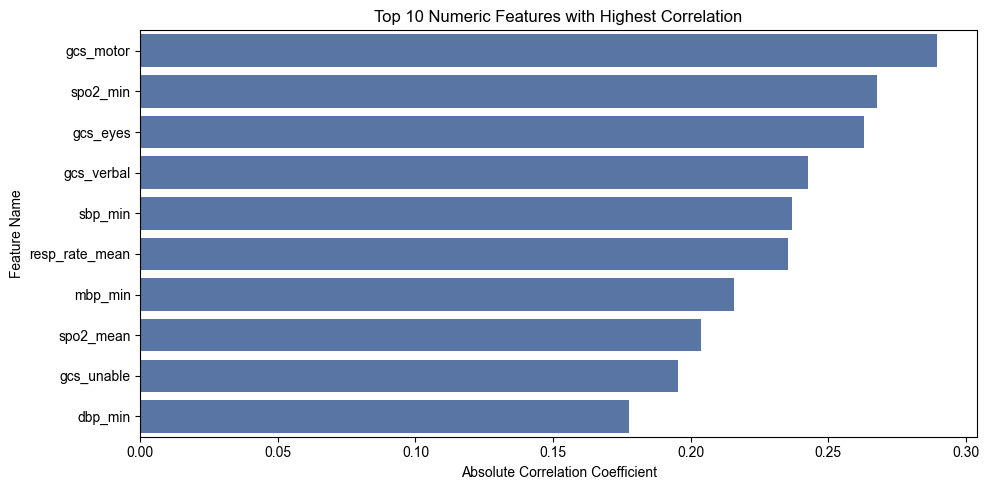

In [30]:
# Absolute Correlation Coefficient (Numeric Feat vs Target)
plt.figure(figsize=(8, 4))
sns.histplot(abs(corr_scores), bins=15, color='#4C72B0', edgecolor='white', alpha=0.8)
plt.axvline(x=0.1, color='#C44E52', linestyle='--', linewidth=2, label='Threshold = 0.1')
plt.title('Absolute Correlation Coefficient (Numeric Feat vs Target)')
plt.xlabel('Absolute Correlation Coefficient')
plt.ylabel('Number of Features')
plt.legend()
plt.tight_layout()
plt.savefig("correlation_distribution.png", bbox_inches="tight")
plt.show()
plt.close()

# Top 10 Numeric Features with Highest Correlation
top10_corr = corr_scores.abs().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top10_corr.values, y=top10_corr.index, color='#4C72B0')
plt.title('Top 10 Numeric Features with Highest Correlation')
plt.xlabel('Absolute Correlation Coefficient')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.savefig("top10_correlation_features.png", bbox_inches="tight")
plt.show()
plt.close()

In [31]:
# Mutual Information (Categorical Features)
cat_cols_var = X_var.select_dtypes(exclude=[np.number]).columns.tolist()
mi_features = []
if len(cat_cols_var) > 0:
    # Calculate mutual information score
    mi_scores = mutual_info_classif(X_var[cat_cols_var], y, random_state=42)
    # retain features with MI > 0.05
    mi_support = mi_scores > 0.05
    mi_features = [cat_cols_var[i] for i, val in enumerate(mi_support) if val]
feat_stage['After mutual information screening'] = len(mi_features)
print(f"The number of classification features after mutual information filtering: {len(mi_features)}")

The number of classification features after mutual information filtering: 0


In [33]:
filtered_features = list(set(corr_features + mi_features)) 
X_filtered = X_var[filtered_features].copy() 
feat_stage['Filter method final'] = X_filtered.shape[1]
print(f"The filtering method ultimately retains the number of features: {X_filtered.shape[1]}")

The filtering method ultimately retains the number of features: 26


#### Phase 2: Refined Screening with RFE

In [58]:
X_train_filtered, _, y_train_rfe, _ = train_test_split(
    X_filtered, y, test_size=0.2, random_state=42, stratify=y  
)
print(f"RFE training set shape: {X_train_filtered.shape} | Training set target distribution: {pd.Series(y_train_rfe).value_counts().to_dict()}")

rfe = RFE(
    estimator=LogisticRegression(max_iter=1000, random_state=42), 
    n_features_to_select=None,  
    step=1, 
    verbose=1  
)
rfe.fit(X_train_filtered, y_train_rfe)  

rfe_support = rfe.support_  
X_selected = X_filtered.iloc[:, rfe_support]  
selected_features = X_selected.columns.tolist() 
feat_stage['RFE final'] = X_selected.shape[1]

print(f"Number of final features after RFE screening: {X_selected.shape[1]}")
print("The list of finally selected features:", selected_features[:10], "...(total:{})".format(len(selected_features)))

RFE training set shape: (52292, 26) | Training set target distribution: {0: 47755, 1: 4537}
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 features.
Fitting estimator with 21 features.
Fitting estimator with 20 features.
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Number of final features after RFE screening: 13
The list of finally selected features: ['sofa2_renal_24h_max', 'heart_rate_max', 'po2_max', 'temperature_mean', 'sbp_min', 'gcs_eyes', 'glucose_min', 'resp_rate_mean', 'sofa2_liver_24h_max', 'spo2_min'] ...(total:13)


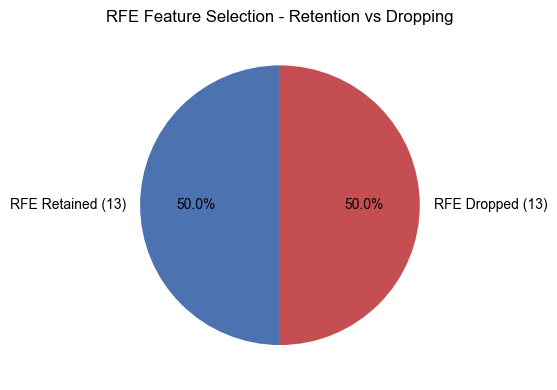

In [41]:
rfe_keep = X_selected.shape[1]
rfe_drop = X_filtered.shape[1] - rfe_keep
plt.figure(figsize=(6, 4))
plt.pie([rfe_keep, rfe_drop], labels=[f'RFE Retained ({rfe_keep})', f'RFE Dropped ({rfe_drop})'],
        colors=['#4C72B0', '#C44E52'], autopct='%1.1f%%', startangle=90)
plt.title('RFE Feature Selection - Retention vs Dropping')
plt.tight_layout()
plt.savefig("rfe_retention_result.png", bbox_inches="tight")
plt.show()
plt.close()

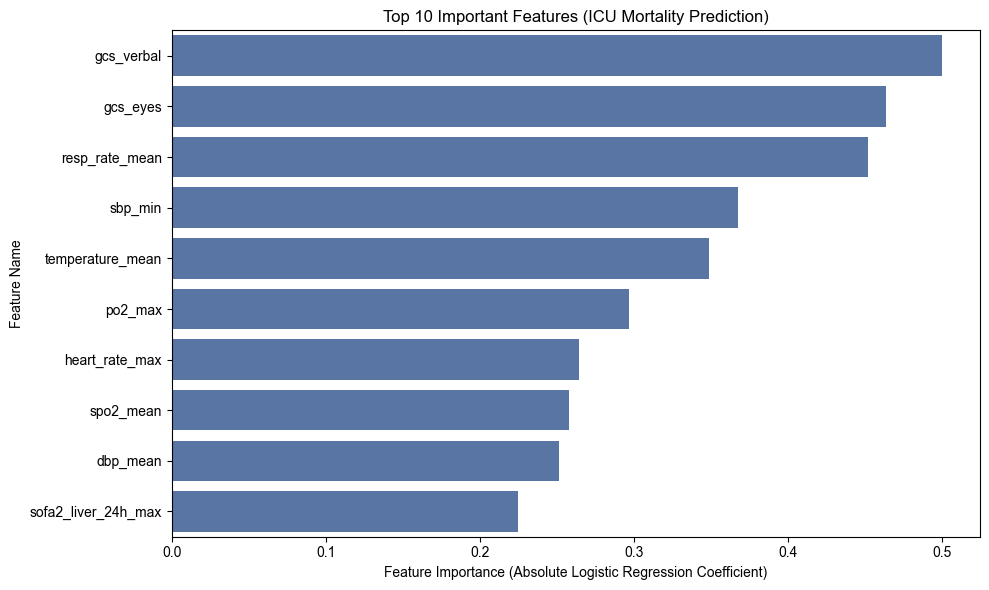


Feature selection completed!
Selected feature matrix shape: (65366, 13)
Final selected features: ['sofa2_renal_24h_max', 'heart_rate_max', 'po2_max', 'temperature_mean', 'sbp_min', 'gcs_eyes', 'glucose_min', 'resp_rate_mean', 'sofa2_liver_24h_max', 'spo2_min', 'gcs_verbal', 'spo2_mean', 'dbp_mean']


In [44]:
plt.figure(figsize=(10, 6))
feat_importance = pd.DataFrame({
    "feature": selected_features,
    "importance": np.abs(rfe.estimator_.coef_[0])
}).sort_values("importance", ascending=False)
sns.barplot(x="importance", y="feature", data=feat_importance.head(10), color='#4C72B0')
plt.title("Top 10 Important Features (ICU Mortality Prediction)")
plt.xlabel("Feature Importance (Absolute Logistic Regression Coefficient)")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()
plt.close()

print("\nFeature selection completed!")
print(f"Selected feature matrix shape: {X_selected.shape}")
print(f"Final selected features: {selected_features}")

### 4. Model Implementation and Performance Comparison

In [45]:
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# Data Split: The dataset is divided into training set and test set.
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Training set target distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test set target distribution: {pd.Series(y_test).value_counts().to_dict()}")

# Initialize the model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10, class_weight="balanced"),
    "SVM": SVC(probability=True, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=100, random_state=42),  # 新增
    "Gradient Boost": GradientBoostingClassifier(n_estimators=100, random_state=42)  # 新增
}
print(f"\nInitialized {len(models)} models: {list(models.keys())}")


Training set: (52292, 13), Test set: (13074, 13)
Training set target distribution: {0: 47755, 1: 4537}
Test set target distribution: {0: 11940, 1: 1134}

Initialized 6 models: ['Logistic Regression', 'Decision Tree', 'SVM', 'Random Forest', 'AdaBoost', 'Gradient Boost']



=== Training Logistic Regression ===
5-fold CV AUC: 0.881
Test set AUC: 0.878
Test set Accuracy: 0.810, F1-Score: 0.414

=== Training Decision Tree ===
5-fold CV AUC: 0.759
Test set AUC: 0.785
Test set Accuracy: 0.805, F1-Score: 0.382

=== Training SVM ===
5-fold CV AUC: 0.881
Test set AUC: 0.883
Test set Accuracy: 0.842, F1-Score: 0.464

=== Training Random Forest ===
5-fold CV AUC: 0.896
Test set AUC: 0.896
Test set Accuracy: 0.929, F1-Score: 0.378

=== Training AdaBoost ===
5-fold CV AUC: 0.885
Test set AUC: 0.889
Test set Accuracy: 0.927, F1-Score: 0.462

=== Training Gradient Boost ===
5-fold CV AUC: 0.901
Test set AUC: 0.903
Test set Accuracy: 0.934, F1-Score: 0.473


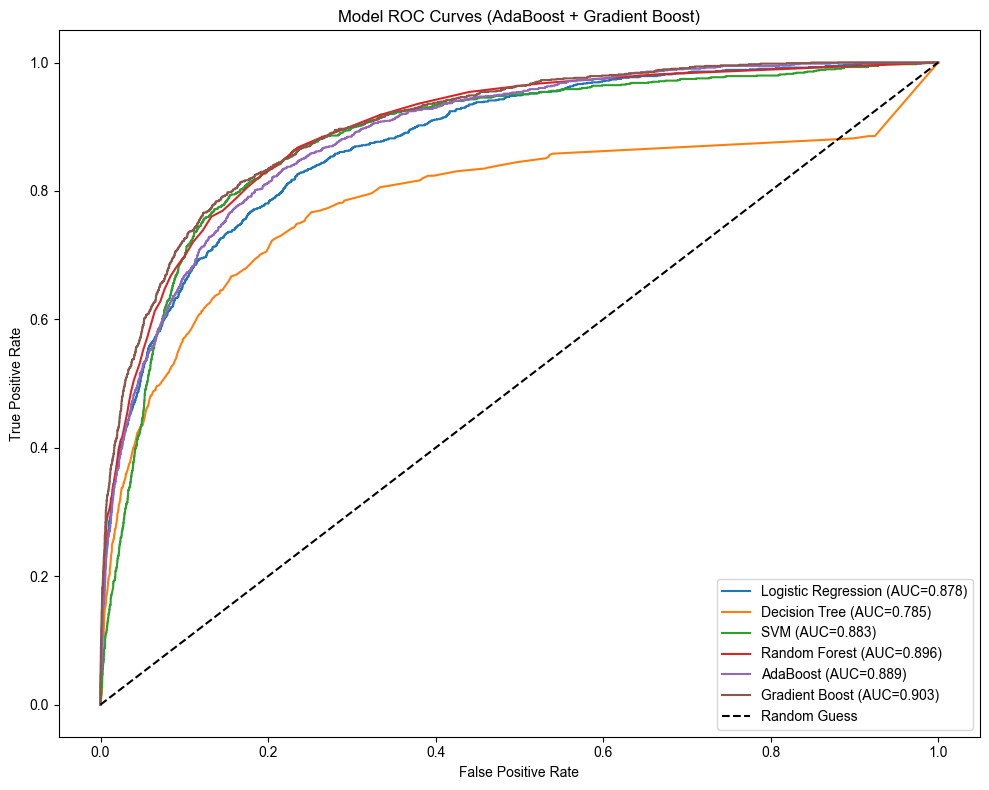

In [52]:
# Training and Evaluation
results = []  
plt.figure(figsize=(10, 8)) 

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    
    cv_auc = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc").mean()
    print(f"5-fold CV AUC: {cv_auc:.3f}")
    
    model.fit(X_train, y_train) 
    y_pred = model.predict(X_test) 
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        "Model": name,
        "CV AUC": cv_auc,
        "Test AUC": roc_auc_score(y_test, y_pred_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    }
    results.append(metrics)
    print(f"Test set AUC: {metrics['Test AUC']:.3f}")
    print(f"Test set Accuracy: {metrics['Accuracy']:.3f}, F1-Score: {metrics['F1']:.3f}")
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={metrics['Test AUC']:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model ROC Curves (AdaBoost + Gradient Boost)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves_updated.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [54]:
# Model Performance Results
results_df = pd.DataFrame(results).sort_values("Test AUC", ascending=False)
print("\n=== Model Performance Comparison ===")
print(results_df.round(3))

results_df.to_csv("model_performance_updated.csv", index=False)


=== Model Performance Comparison ===
                 Model  CV AUC  Test AUC  Accuracy  Precision  Recall     F1
5       Gradient Boost   0.901     0.903     0.934      0.757   0.344  0.473
3        Random Forest   0.896     0.896     0.929      0.801   0.248  0.378
4             AdaBoost   0.885     0.889     0.927      0.637   0.362  0.462
2                  SVM   0.881     0.883     0.842      0.329   0.788  0.464
0  Logistic Regression   0.881     0.878     0.810      0.282   0.772  0.414
1        Decision Tree   0.759     0.785     0.805      0.263   0.694  0.382


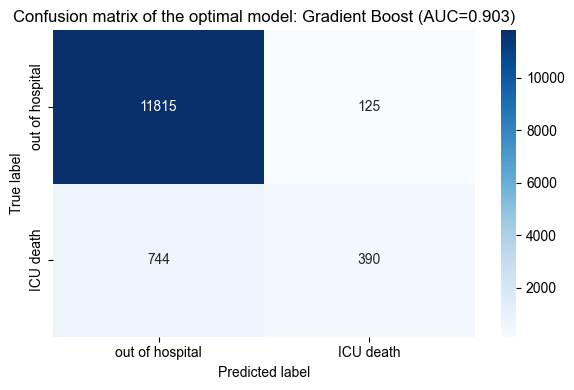

In [55]:
#Confusion Matrix
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_auc = results_df.iloc[0]["Test AUC"]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["out of hospital", "ICU death"],
            yticklabels=["out of hospital", "ICU death"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion matrix of the optimal model: {best_model_name} (AUC={best_auc:.3f})")
plt.tight_layout()
plt.savefig("confusion_matrix_updated.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


In [57]:
print(f"Optimal model: {best_model_name} (Test AUC={best_auc:.3f})")

Optimal model: Gradient Boost (Test AUC=0.903)
